## Exercise 2, Particle in a one-dimensional potential

* **2g. (5 pts)** Write a numerical algorithm to find the position and velocity of the particle at a time $t+\Delta t$ given the position and velocity at a time $t$. Here you can use either the standard forward Euler, or the Euler-Cromer or the Velocity Verlet algorithms.   You need to justify your choice here (hint: consider energy conservation). **You might find this [numerical integration resource](../resources/integrators.ipynb) helpful.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def traj_solver(x0, v0, t0, tf, V0, d, m):
    dt = 0.01
    N = int((tf-t0)/dt)
    t = np.linspace(t0, tf, N)
    x = np.zeros(N)
    v = np.zeros(N)
    a = np.zeros(N)
    x[0] = x0
    v[0] = v0
    a[0] = 4*V0/(m*d**4) * x0 * (d**2 - x0**2)

    for  i in range(1, N):
        x[i] = x[i-1] + v[i-1] * dt + 0.5 * a[i-1] * dt**2
        a[i] = 4*V0/(m*d**4) * x[i] * (d**2 - x[i]**2)
        v[i] = v[i-1] + 0.5 * (a[i] + a[i-1]) * dt

    return [x, v]

* **2h. (5 pts)** Use now your program to find the position of the particle as function of time from $t=0$ to $t=30$ s using a mass  $m=1.0$ kg, the parameter $V_0=1$ J and $d=0.1$ m. Make a plot of three distinct positions with initial conditions $x_0=d$ and $v_0=0.5$ m/s, $x_0=d$ and $v_0=1.5$ m/s, and $x_0=d$ and $v_0=2.5$ m/s. Plot the velocity.  Perform these analyses with and without the term $x^4$ in the potential. Do you see a difference? What do you notice?

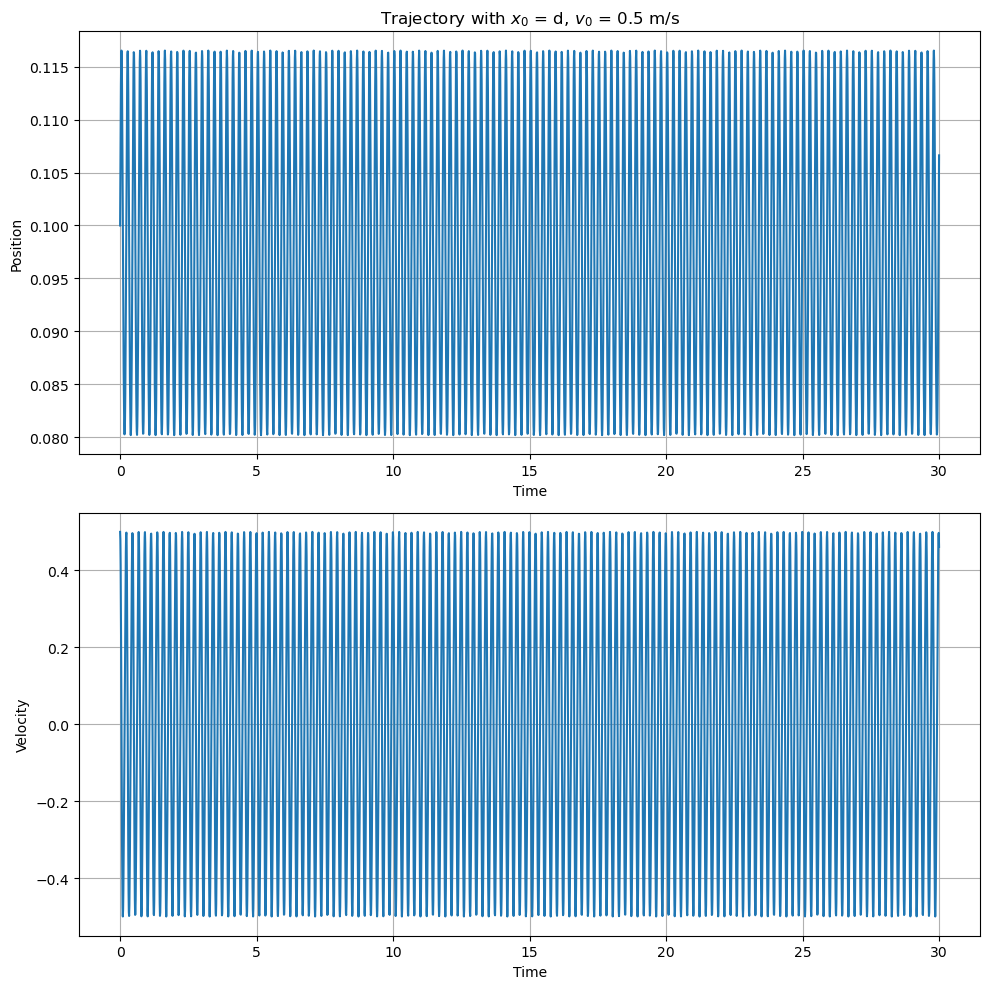

In [16]:
 
x1  = traj_solver(0.1, 0.5, 0, 30, 1, 0.1, 1)[0]
v1  = traj_solver(0.1, 0.5, 0, 30, 1, 0.1, 1)[1]
t0 = 0
tf = 30
dt = 0.01 
N = int((tf-t0)/dt)
t = np.linspace(0, 30, N)
fig, ax = plt.subplots(2, 1, figsize=(10, 10))
ax[0].set_title('Trajectory with $x_0$ = d, $v_0$ = 0.5 m/s')
ax[0].plot(t, x1, label='Position')
ax[0].set_ylabel('Position')
ax[0].set_xlabel('Time')
ax[0].grid(True)

ax[1].plot(t, v1, label='Velocity')
ax[1].set_ylabel('Velocity')
ax[1].set_xlabel('Time')
ax[1].grid(True)
plt.tight_layout()
plt.show()

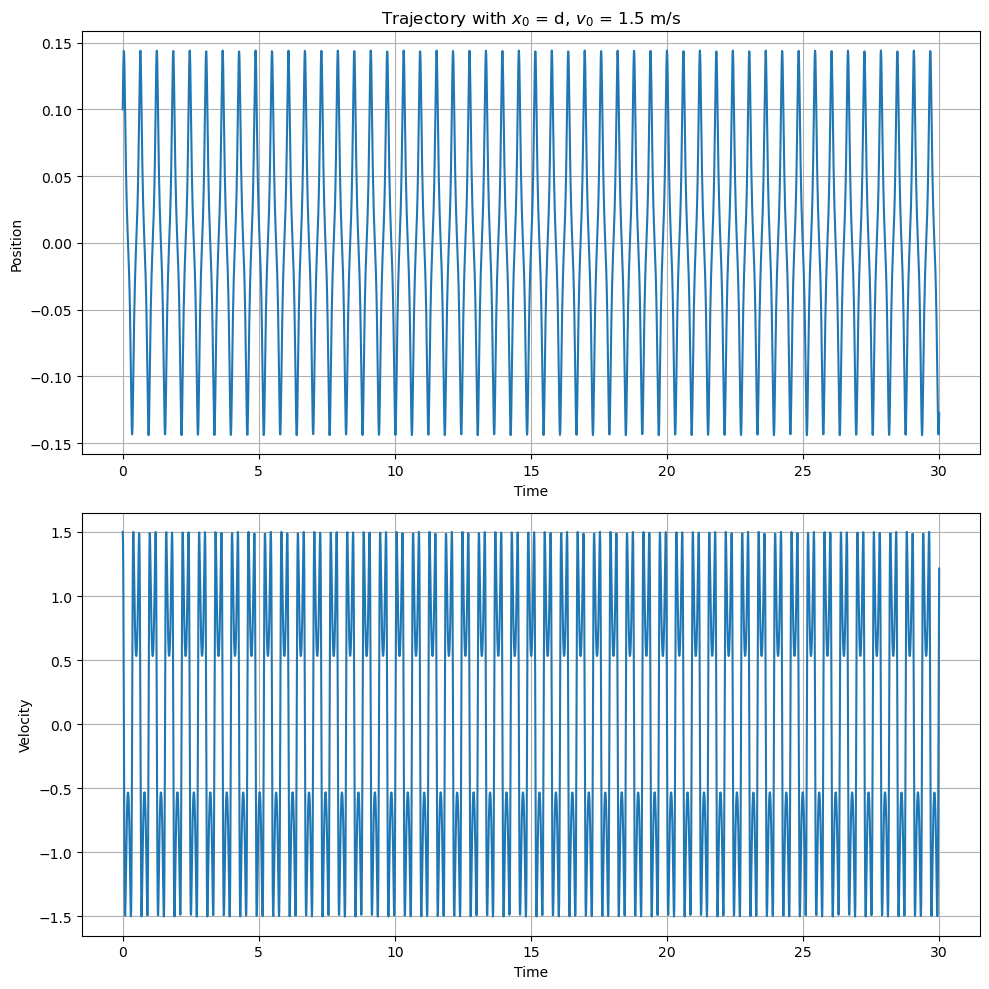

In [18]:
x2  = traj_solver(0.1, 1.5, 0, 30, 1, 0.1, 1)[0]
v2  = traj_solver(0.1, 1.5, 0, 30, 1, 0.1, 1)[1]
fig, ax = plt.subplots(2, 1, figsize=(10, 10))
ax[0].set_title('Trajectory with $x_0$ = d, $v_0$ = 1.5 m/s')
ax[0].plot(t, x2, label='Position')
ax[0].set_ylabel('Position')
ax[0].set_xlabel('Time')
ax[0].grid(True)

ax[1].plot(t, v2, label='Velocity')
ax[1].set_ylabel('Velocity')
ax[1].set_xlabel('Time')
ax[1].grid(True)
plt.tight_layout()
plt.show()

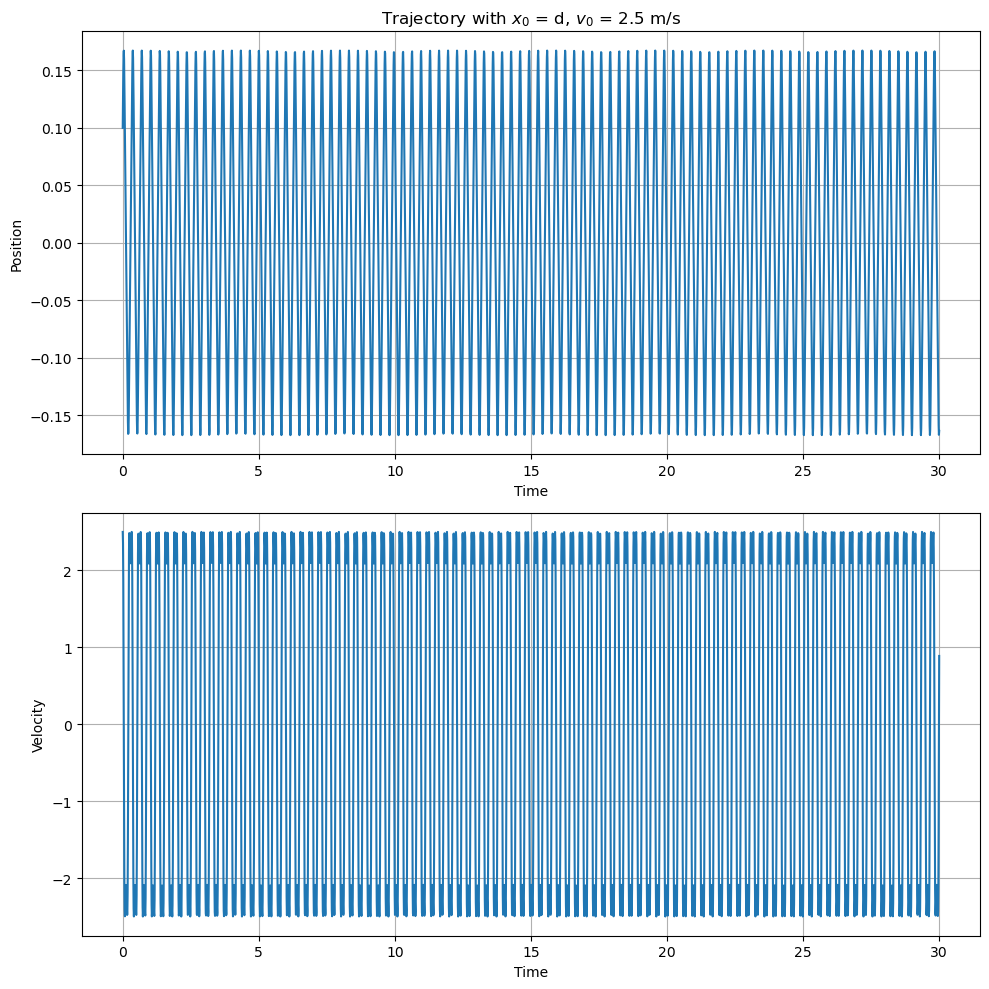

In [19]:
x3  = traj_solver(0.1, 2.5, 0, 30, 1, 0.1, 1)[0]
v3  = traj_solver(0.1, 2.5, 0, 30, 1, 0.1, 1)[1]
fig, ax = plt.subplots(2, 1, figsize=(10, 10))
ax[0].set_title('Trajectory with $x_0$ = d, $v_0$ = 2.5 m/s')
ax[0].plot(t, x3, label='Position')
ax[0].set_ylabel('Position')
ax[0].set_xlabel('Time')
ax[0].grid(True)

ax[1].plot(t, v3, label='Velocity')
ax[1].set_ylabel('Velocity')
ax[1].set_xlabel('Time')
ax[1].grid(True)
plt.tight_layout()
plt.show()

Now plotting the trajectories without the x^4 term in the potential,

In [5]:
def traj_solver2(x0, v0, t0, tf, V0, d, m):
    dt = 0.01
    N = int((tf-t0)/dt)
    t = np.linspace(t0, tf, N)
    x = np.zeros(N)
    v = np.zeros(N)
    a = np.zeros(N)
    x[0] = x0
    v[0] = v0
    a[0] = -4*V0/(m*d**2) * x0

    for  i in range(1, N):
        x[i] = x[i-1] + v[i-1] * dt + 0.5 * a[i-1] * dt**2
        a[i] = -4*V0/(m*d**2) * x[i]
        v[i] = v[i-1] + 0.5 * (a[i] + a[i-1]) * dt

    return [x, v]

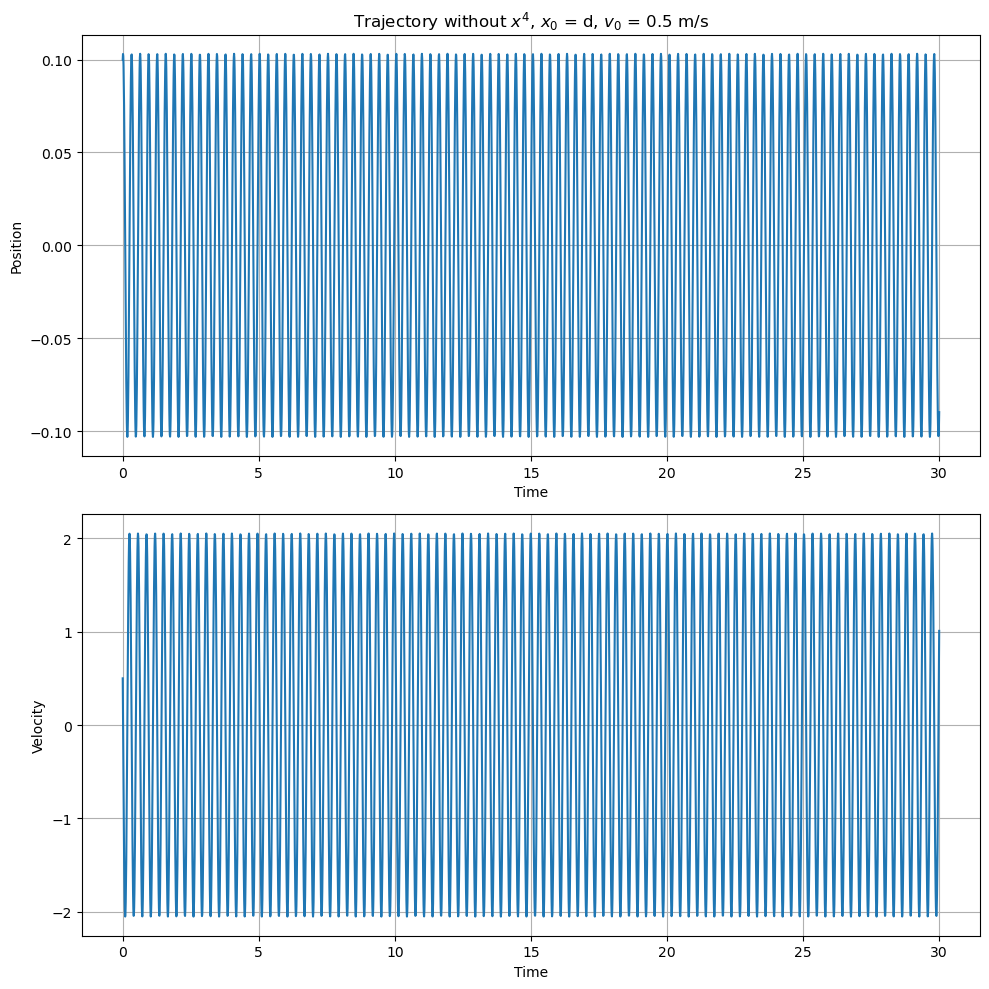

In [21]:
x4  = traj_solver2(0.1, 0.5, 0, 30, 1, 0.1, 1)[0]
v4  = traj_solver2(0.1, 0.5, 0, 30, 1, 0.1, 1)[1]
t = np.linspace(0, 30, 3000)

fig, ax = plt.subplots(2, 1, figsize=(10, 10))
ax[0].set_title('Trajectory without $x^4$, $x_0$ = d, $v_0$ = 0.5 m/s')
ax[0].plot(t, x4, label='Position')
ax[0].set_ylabel('Position')
ax[0].set_xlabel('Time')
ax[0].grid(True)

ax[1].plot(t, v4, label='Velocity')
ax[1].set_ylabel('Velocity')
ax[1].set_xlabel('Time')
ax[1].grid(True)
plt.tight_layout()
plt.show()

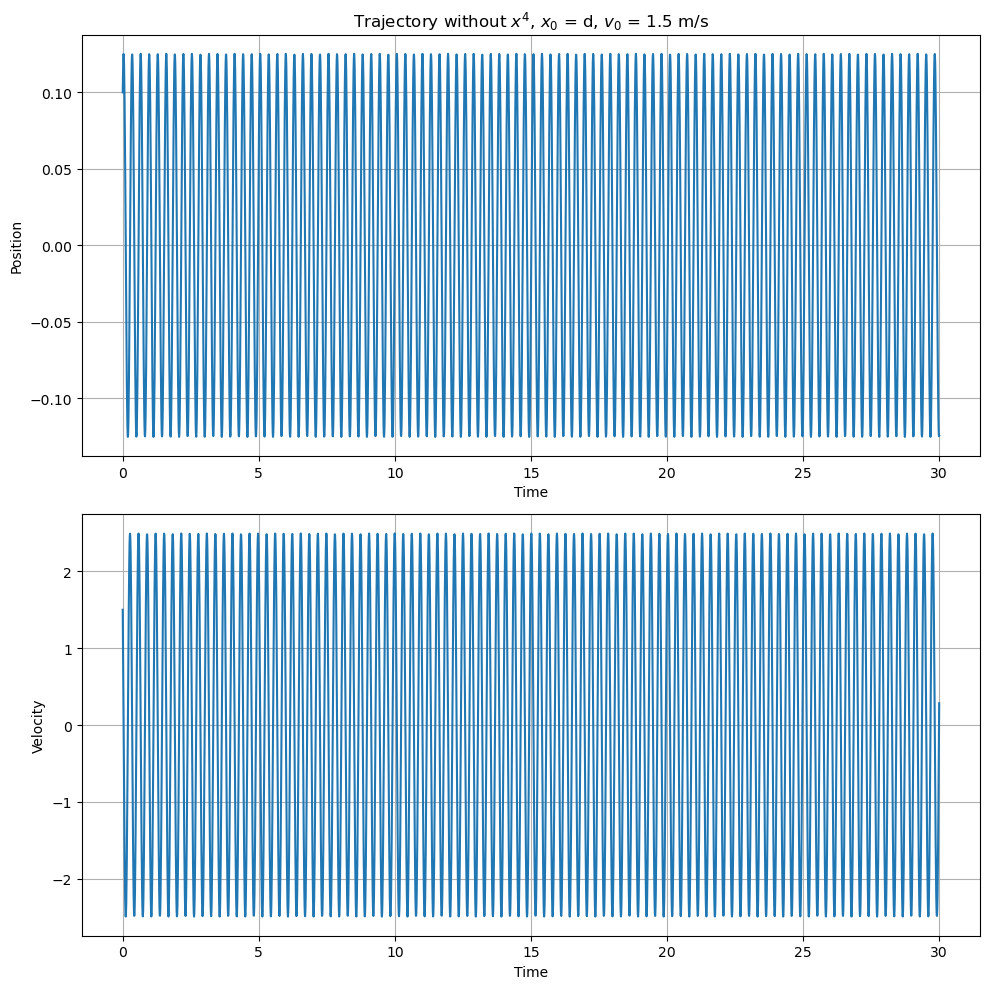

In [22]:
x5  = traj_solver2(0.1, 1.5, 0, 30, 1, 0.1, 1)[0]
v5  = traj_solver2(0.1, 1.5, 0, 30, 1, 0.1, 1)[1]

fig, ax = plt.subplots(2, 1, figsize=(10, 10))
ax[0].set_title('Trajectory without $x^4$, $x_0$ = d, $v_0$ = 1.5 m/s')
ax[0].plot(t, x5, label='Position')
ax[0].set_ylabel('Position')
ax[0].set_xlabel('Time')
ax[0].grid(True)

ax[1].plot(t, v5, label='Velocity')
ax[1].set_ylabel('Velocity')
ax[1].set_xlabel('Time')
ax[1].grid(True)
plt.tight_layout()
plt.show()

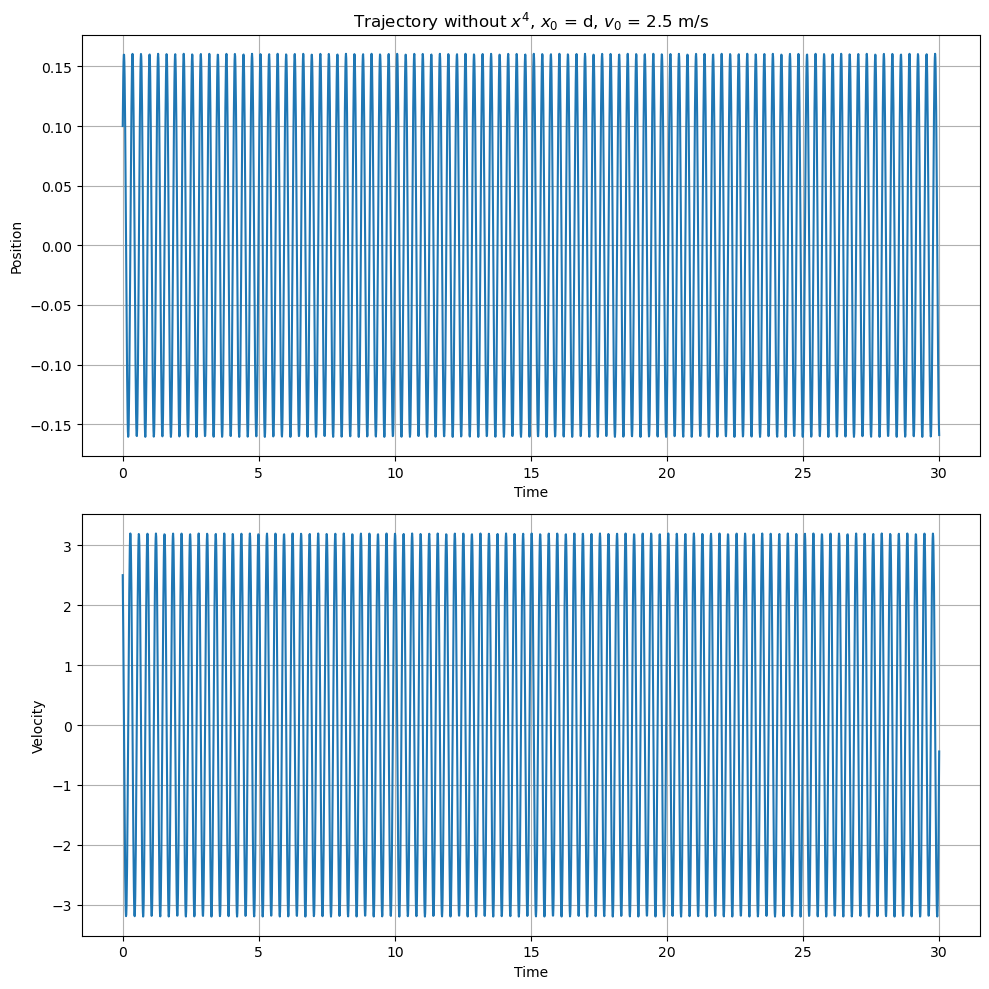

In [23]:
x6  = traj_solver2(0.1, 2.5, 0, 30, 1, 0.1, 1)[0]
v6  = traj_solver2(0.1, 2.5, 0, 30, 1, 0.1, 1)[1]

fig, ax = plt.subplots(2, 1, figsize=(10, 10))
ax[0].set_title('Trajectory without $x^4$, $x_0$ = d, $v_0$ = 2.5 m/s')
ax[0].plot(t, x6, label='Position')
ax[0].set_ylabel('Position')
ax[0].set_xlabel('Time')
ax[0].grid(True)

ax[1].plot(t, v6, label='Velocity')
ax[1].set_ylabel('Velocity')
ax[1].set_xlabel('Time')
ax[1].grid(True)
plt.tight_layout()
plt.show()

By examining the equation for acceleration, we notice the acceleration is directly proportional to displacement which indicates the system is a simple harmonic oscillator. If we zoom into one of the plots,

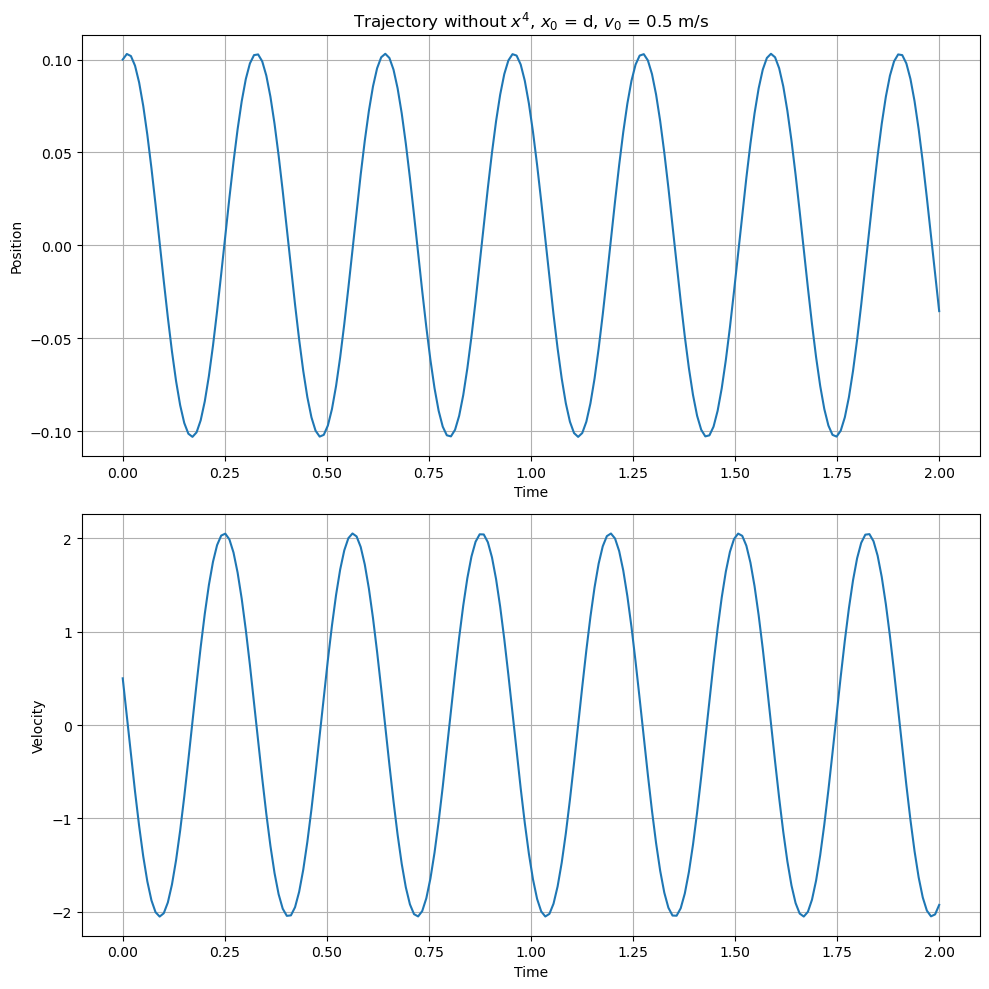

In [24]:
x7  = traj_solver2(0.1, 0.5, 0, 2, 1, 0.1, 1)[0]
v7  = traj_solver2(0.1, 0.5, 0, 2, 1, 0.1, 1)[1]
t2 = np.linspace(0, 2, 200)

fig, ax = plt.subplots(2, 1, figsize=(10, 10))
ax[0].set_title('Trajectory without $x^4$, $x_0$ = d, $v_0$ = 0.5 m/s')
ax[0].plot(t2, x7, label='Position')
ax[0].set_ylabel('Position')
ax[0].set_xlabel('Time')
ax[0].grid(True)

ax[1].plot(t2, v7, label='Velocity')
ax[1].set_ylabel('Velocity')
ax[1].set_xlabel('Time')
ax[1].grid(True)
plt.tight_layout()
plt.show()

This confirms the motion with the potential without the x^4 term is simple harmonic oscillation.

* **2i. (5 pts)** Describe the behavior of the particle for the three initial conditions  and sketch the motion in an energy diagram. Is energy conserved in your simulations?

For $x_0$ = d, $v_0$ = 0.5 m/s, we have the particle oscillating around the x = d position and its velocity oscillates. It does have enough energy to cross the potential barrier of $V_0$ since from its initial total energy 0.5 * 1 * $0.5^2$ + $1/(0.1)^4 (0.1^2 - 0.1^2)^2$ = 0.125J < $V_0$ = 1J.

In [10]:
print('The maximum displacement of the particle =', round(max(x1),4), 'm')
print('The minimum displacement of the particle =', round(min(x1),4), 'm')
print('The particle oscillates between these two positions around x = d = 0.1 m')

The maximum displacement of the particle = 0.1165 m
The minimum displacement of the particle = 0.0802 m
The particle oscillates between these two positions around x = d = 0.1 m


For $x_0$ = d, $v_0$ = 1.5 m/s, we have the particle oscillating around the unstable point x=0 and its velocity oscillates. The particle has enough energy to cross the potential barrier of 1J. 

In [11]:
print('The maximum displacement of the particle =', round(max(x2),4), 'm')
print('The minimum displacement of the particle =', round(min(x2),4), 'm')
print('The particle oscillates between these two positions around x=0 m')

The maximum displacement of the particle = 0.1441 m
The minimum displacement of the particle = -0.1441 m
The particle oscillates between these two positions around x=0 m


For $x_0$ = d, $v_0$ = 2.5 m/s, we have the particle oscillating around the unstable point x = 0 and its velocity oscillates. The particle has enough energy to cross the potential barrier of 1J. 

In [12]:
print('The maximum displacement of the particle =', round(max(x3),4), 'm')
print('The minimum displacement of the particle =', round(min(x3),4), 'm')
print('The particle oscillates between these two positions around x=0 m')

The maximum displacement of the particle = 0.1672 m
The minimum displacement of the particle = -0.1672 m
The particle oscillates between these two positions around x=0 m


The sketches of the energy diagrams with the three initial conditions are attached along with the document.

Now plotting the energies of the particle using the three initial conditions,

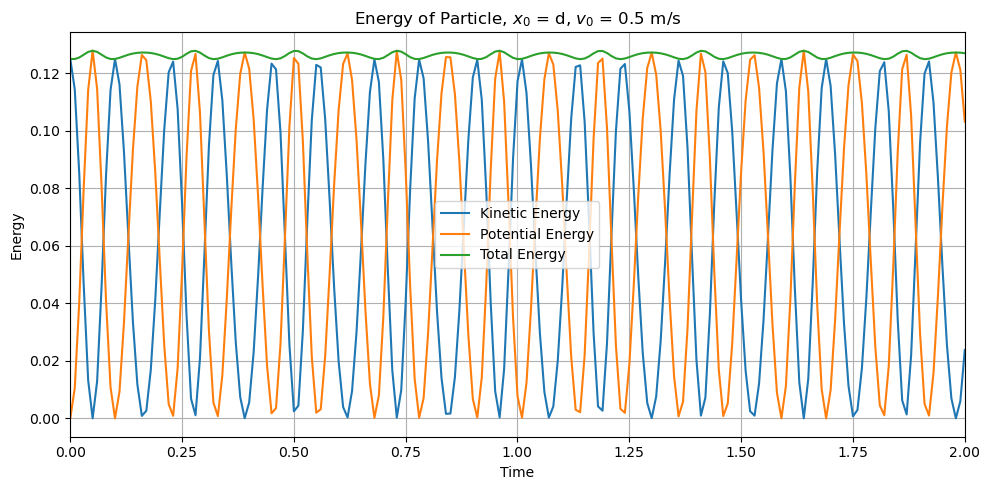

In [13]:
KE1 = 0.5 * 1 * v1**2 
PE1 = (1/(0.1)**4)*(x1**2 - 0.1**2)**2
ETOT1 = 0.5 * 1 * v1**2 + (1/(0.1)**4)*(x1**2 - 0.1**2)**2

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.set_title('Energy of Particle, $x_0$ = d, $v_0$ = 0.5 m/s')
ax.plot(t, KE1, label='Kinetic Energy')
ax.plot(t, PE1, label='Potential Energy')
ax.plot(t, ETOT1, label='Total Energy')
ax.set_ylabel('Energy')
ax.set_xlabel('Time')
ax.legend()
ax.grid(True)
ax.set_xlim(0,2)


plt.tight_layout()
plt.show()

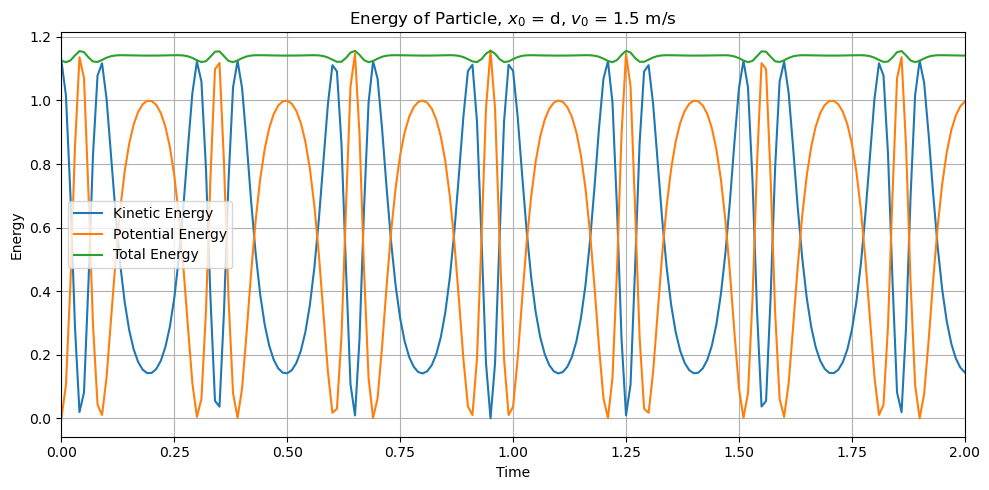

In [14]:
KE2 = 0.5 * 1 * v2**2 
PE2 = (1/(0.1)**4)*(x2**2 - 0.1**2)**2
ETOT2 = 0.5 * 1 * v2**2 + (1/(0.1)**4)*(x2**2 - 0.1**2)**2

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.set_title('Energy of Particle, $x_0$ = d, $v_0$ = 1.5 m/s')
ax.plot(t, KE2, label='Kinetic Energy')
ax.plot(t, PE2, label='Potential Energy')
ax.plot(t, ETOT2, label='Total Energy')
ax.set_ylabel('Energy')
ax.set_xlabel('Time')
ax.legend()
ax.grid(True)
ax.set_xlim(0,2)


plt.tight_layout()
plt.show()

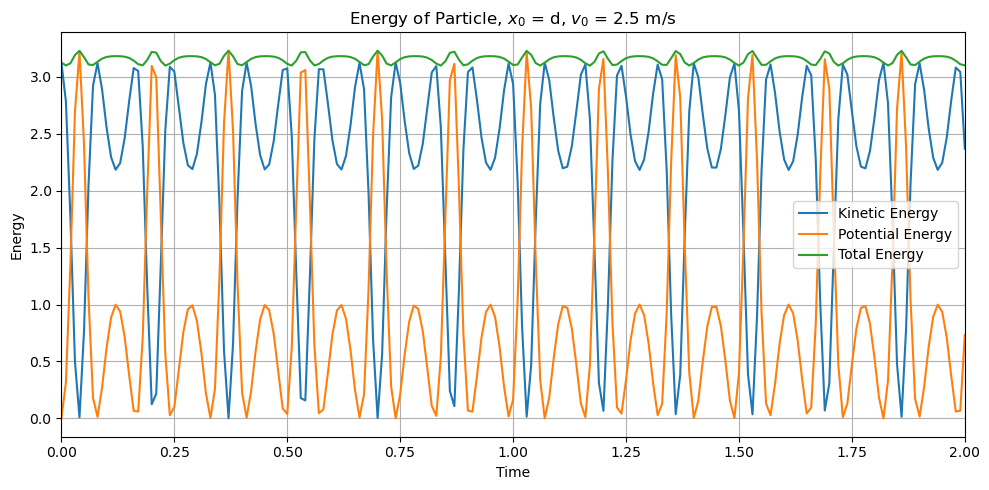

In [15]:
KE3 = 0.5 * 1 * v3**2 
PE3 = (1/(0.1)**4)*(x3**2 - 0.1**2)**2
ETOT3 = 0.5 * 1 * v3**2 + (1/(0.1)**4)*(x3**2 - 0.1**2)**2

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.set_title('Energy of Particle, $x_0$ = d, $v_0$ = 2.5 m/s')
ax.plot(t, KE3, label='Kinetic Energy')
ax.plot(t, PE3, label='Potential Energy')
ax.plot(t, ETOT3, label='Total Energy')
ax.set_ylabel('Energy')
ax.set_xlabel('Time')
ax.legend()
ax.grid(True)
ax.set_xlim(0,2)


plt.tight_layout()
plt.show()

This shows energy is not totally conserved in these simulations even with the velocity-verlet algorithm but it can serve as a good approximation.